In [13]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
from dotenv import load_dotenv
import os 

load_dotenv()

True

In [4]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="What to cover")

In [5]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [27]:
class State(TypedDict):
    topic: str
    plan: Plan
    # reducer: results from workers get concatenated automatically
    sections: Annotated[List[str], operator.add]
    final: str

In [11]:
api_key = os.getenv("GROQ_API_KEY")

In [14]:
llm=ChatGroq(model="openai/gpt-oss-120b")

In [22]:
def orchestrator(state: State) -> dict:

    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "Create a blog plan with 5-7 sections on the following topic."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    return {"plan": plan}

In [23]:
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks]

In [24]:
def worker(payload: dict) -> dict:

    # payload contains what we sent
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}

In [40]:
from pathlib import Path
import re
import unicodedata

def _safe_filename(title: str) -> str:
    name = unicodedata.normalize("NFKD", title or "output")
    name = name.encode("ascii", "ignore").decode()
    name = re.sub(r"[^A-Za-z0-9 _-]", "", name).strip().lower().replace(" ", "_")
    if not name:
        name = "output"
    return f"{name}.md"

def save_markdown(content: str, title: str, out_dir: str = "outputs") -> Path:
    out = Path(out_dir)
    out.mkdir(parents=True, exist_ok=True)
    filename = _safe_filename(title)
    path = out / filename
    if not content or not content.strip():
        raise ValueError("Empty content — not writing file.")
    path.write_text(content, encoding="utf-8")
    return path

def reducer(state: State) -> dict:
    title = state["plan"].blog_title
    sections = state.get("sections", [])
    body = "\n\n".join(sections).strip()
    final_md = f"# {title}\n\n{body}\n"
    # debug info
    print("--- Reducer debug ---")
    print("CWD:", Path.cwd())
    print("Title:", title)
    print("final_md length:", len(final_md))
    try:
        out_path = save_markdown(final_md, title, out_dir="outputs")
        print(f"Wrote {out_path} ({out_path.stat().st_size} bytes)")
    except ValueError as e:
        print("Not writing file:", e)

    return {"final": final_md}

In [41]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

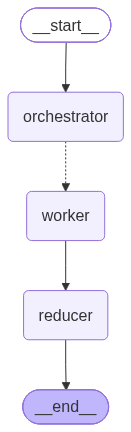

In [42]:
g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

app

In [43]:
out = app.invoke({"topic": "Write a blog on Self Attention"})

--- Reducer debug ---
CWD: d:\Programming\PROJECTS\Blog-generator
Title: Demystifying Self-Attention: How Transformers See the World
final_md length: 26291
Wrote outputs\demystifying_self-attention_how_transformers_see_the_world.md (27388 bytes)


In [44]:
out

{'topic': 'Write a blog on Self Attention',
 'plan': Plan(blog_title='Demystifying Self-Attention: How Transformers See the World', tasks=[Task(id=1, title='Introduction to Attention Mechanisms', brief='Explain the motivation behind attention in neural networks, contrasting it with traditional sequence models and setting the stage for self-attention.'), Task(id=2, title='What Is Self-Attention?', brief='Define self-attention, illustrate the core idea of a token attending to every other token in the same sequence, and why it matters.'), Task(id=3, title='Mathematical Formulation', brief='Walk through the key equations: query, key, value vectors, scaled dot‑product, softmax weighting, and the final weighted sum. Include a simple numeric example.'), Task(id=4, title='Multi‑Head Self-Attention', brief='Describe why multiple attention heads are used, how they capture different sub‑spaces, and the process of concatenation and linear projection.'), Task(id=5, title='Self-Attention in the Tran